In [28]:
import numpy as np
import math
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [29]:
%pip install seaborn


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [30]:
df = pd.read_csv("table_tableau08.csv")

In [31]:
df

,Political affiliation/Appartenance politique,N.L. Valid Votes/Votes valides T.-N.-L.,P.E.I. Valid Votes/Votes valides Î.-P.-É.,N.S. Valid Votes/Votes valides N.-É.,N.B. Valid Votes/Votes valides N.-B.,Que. Valid Votes/Votes valides Qc,Ont. Valid Votes/Votes valides Ont.,Man. Valid Votes/Votes valides Man.,Sask. Valid Votes/Votes valides Sask.,Alta. Valid Votes/Votes valides Alb.,B.C. Valid Votes/Votes valides C.-B.,Y.T. Valid Votes/Votes valides Yn,N.W.T. Valid Votes/Votes valides T.N.-O.,Nun. Valid Votes/Votes valides Nt
0,Animal Protection Party of Canada/Le Parti pou...,170,0,0,0,0,723,213,0,0,195,0,0,0
1,Bloc Québécois/Bloc Québécois,0,0,0,0,1236349,0,0,0,0,0,0,0,0
2,Canadian Future Party/Parti Avenir Canadien,0,0,169,345,0,872,0,568,1079,90,0,0,0
3,Centrist Party of Canada/Parti Centriste du Ca...,0,0,0,44,60,3103,0,0,107,0,0,0,0
4,Christian Heritage Party of Canada/Parti de l'...,0,0,0,0,181,5193,0,0,3604,1087,0,0,0
5,Communist Party of Canada/Parti communiste du ...,98,0,0,146,572,1707,428,0,865,869,0,0,0
6,Conservative Party of Canada/Parti conservateu...,110259,35846,204051,190429,1040992,3324929,297510,362495,1442094,1088655,8719,5513,1992
7,Green Party of Canada/Le Parti Vert du Canada,299,2170,5448,7982,40795,85907,4579,2869,8944,79255,474,170,0
8,Liberal Party of Canada/Parti libéral du Canada,150458,56011,332354,250659,1904206,3730652,261113,149397,631929,1105033,12009,8855,2812
9,Libertarian Party of Canada/Parti Libertarien ...,0,0,320,776,0,2484,0,226,623,1132,0,0,0


How many seats does each province elect?

In [32]:
seat_allocation = {
    # Provinces
    "ON": 122,
    "QC": 78,
    "BC": 43,
    "AB": 37,
    "MB": 14,
    "SK": 14,
    "NS": 11,
    "NB": 10,
    "NL": 7,
    "PE": 4,
    "NU": 1,
    "YT": 1,
    "NT": 1
}

2025 official results

In [33]:
national_results_2025_fptp = {
    "Liberal Party of Canada": 169,
    "Conservative Party of Canada": 144,
    "Bloc Québécois": 22,
    "New Democratic Party": 7,
    "Green Party of Canada": 1
}

In [34]:
df = df.reset_index()
df_melt = df.melt(
    id_vars="Political affiliation/Appartenance politique",
    var_name="Province",
    value_name="Votes"
)

In [35]:
df_melt

,Political affiliation/Appartenance politique,Province,Votes
0,Animal Protection Party of Canada/Le Parti pou...,index,0
1,Bloc Québécois/Bloc Québécois,index,1
2,Canadian Future Party/Parti Avenir Canadien,index,2
3,Centrist Party of Canada/Parti Centriste du Ca...,index,3
4,Christian Heritage Party of Canada/Parti de l'...,index,4
...,...,...,...
247,Parti Rhinocéros Party/Parti Rhinocéros Party,Nun. Valid Votes/Votes valides Nt,0
248,People's Party of Canada/Parti populaire du Ca...,Nun. Valid Votes/Votes valides Nt,0
249,United Party of Canada (UP)/Parti Uni du Canad...,Nun. Valid Votes/Votes valides Nt,0
250,Independent/Indépendant(e),Nun. Valid Votes/Votes valides Nt,0


In [36]:
NS = df_melt[df_melt["Province"] == "N.S. Valid Votes/Votes valides N.-É."]
PE = df_melt[df_melt["Province"] == "P.E.I. Valid Votes/Votes valides Î.-P.-É."]
ON = df_melt[df_melt["Province"] == "Ont. Valid Votes/Votes valides Ont."]
QC = df_melt[df_melt["Province"] == "Que. Valid Votes/Votes valides Qc"]
SK = df_melt[df_melt["Province"] == "Sask. Valid Votes/Votes valides Sask."]
MB = df_melt[df_melt["Province"] == "Man. Valid Votes/Votes valides Man."]
NB = df_melt[df_melt["Province"] == "Sask. Valid Votes/Votes valides Sask."]
NL = df_melt[df_melt["Province"] == "N.L. Valid Votes/Votes valides T.-N.-L."]
AB = df_melt[df_melt["Province"] == "Alta. Valid Votes/Votes valides Alb."]
BC = df_melt[df_melt["Province"] == "B.C. Valid Votes/Votes valides C.-B."]
NT = df_melt[df_melt["Province"] == "N.W.T. Valid Votes/Votes valides T.N.-O."]
NU = df_melt[df_melt["Province"] == "Nun. Valid Votes/Votes valides Nt"]
YT = df_melt[df_melt["Province"] == "Y.T. Valid Votes/Votes valides Yn"]

In [37]:
def dhondt(province, seats):
    votes = dict(zip(
        province["Political affiliation/Appartenance politique"],
        province["Votes"]
    ))
    
    allocation = {party: 0 for party in votes}
    quotients = []

    for party, vote in votes.items():
        for i in range(1, seats + 1):
            quotients.append((party, vote / i))

    quotients.sort(key=lambda x: x[1], reverse=True)

    for i in range(seats):
        party = quotients[i][0]
        allocation[party] += 1

    return allocation

In [38]:
province_dfs = {
    "NL": NL, "PE": PE, "NS": NS, "NB": NB, "QC": QC, "ON": ON,
    "MB": MB, "SK": SK, "AB": AB, "BC": BC, "NT": NT, "NU": NU, "YT": YT
}

results_by_province = {}

for code, province_df in province_dfs.items():
    seats = seat_allocation.get(code, 0)

    if seats > 0 and not province_df.empty:
        results_by_province[code] = dhondt(province_df, seats)
    else:
        results_by_province[code] = {}

In [39]:
results_by_province

{'NL': {'Animal Protection Party of Canada/Le Parti pour la Protection des Animaux du Canada': 0,
  'Bloc Québécois/Bloc Québécois': 0,
  'Canadian Future Party/Parti Avenir Canadien': 0,
  'Centrist Party of Canada/Parti Centriste du Canada': 0,
  "Christian Heritage Party of Canada/Parti de l'Héritage Chrétien du Canada": 0,
  'Communist Party of Canada/Parti communiste du Canada': 0,
  'Conservative Party of Canada/Parti conservateur du Canada': 3,
  'Green Party of Canada/Le Parti Vert du Canada': 0,
  'Liberal Party of Canada/Parti libéral du Canada': 4,
  'Libertarian Party of Canada/Parti Libertarien du Canada': 0,
  'Marijuana Party/Parti Marijuana': 0,
  'Marxist-Leninist Party of Canada/Parti Marxiste-Léniniste du Canada': 0,
  'New Democratic Party/Nouveau Parti démocratique': 0,
  'Parti Rhinocéros Party/Parti Rhinocéros Party': 0,
  "People's Party of Canada/Parti populaire du Canada": 0,
  'United Party of Canada (UP)/Parti Uni du Canada (UP)': 0,
  'Independent/Indépenda

In [40]:
import pandas as pd

df_seats = pd.concat(
    {d: pd.Series(p) for d, p in results_by_province.items()},
    names=["district", "party"]
).reset_index(name="seats")

In [41]:
df_seats

,district,party,seats
0,NL,Animal Protection Party of Canada/Le Parti pou...,0
1,NL,Bloc Québécois/Bloc Québécois,0
2,NL,Canadian Future Party/Parti Avenir Canadien,0
3,NL,Centrist Party of Canada/Parti Centriste du Ca...,0
4,NL,Christian Heritage Party of Canada/Parti de l'...,0
...,...,...,...
229,YT,Parti Rhinocéros Party/Parti Rhinocéros Party,0
230,YT,People's Party of Canada/Parti populaire du Ca...,0
231,YT,United Party of Canada (UP)/Parti Uni du Canad...,0
232,YT,Independent/Indépendant(e),0


In [42]:
df_seats = df_seats[df_seats["seats"] > 0]
df_seats["party"] = df_seats["party"].str.split("/").str[0]

In [43]:
df_seats = df_seats.sort_values(["district", "seats"], ascending=[True, False])

In [44]:
national_results_dhondt = (
    df_seats
    .groupby("party", as_index=False)["seats"]
    .sum()
    .sort_values("seats", ascending=False)
)

In [45]:
df_seats

,district,party,seats
150,AB,Conservative Party of Canada,25
152,AB,Liberal Party of Canada,10
156,AB,New Democratic Party,2
170,BC,Liberal Party of Canada,19
168,BC,Conservative Party of Canada,18
174,BC,New Democratic Party,5
169,BC,Green Party of Canada,1
114,MB,Conservative Party of Canada,7
116,MB,Liberal Party of Canada,6
120,MB,New Democratic Party,1


In [46]:
national_results_dhondt

,party,seats
3,Liberal Party of Canada,153
1,Conservative Party of Canada,147
0,Bloc Québécois,22
4,New Democratic Party,19
2,Green Party of Canada,2


In [47]:
sum(national_results_dhondt['seats'])

343

As we can see, the results experience major changes. 
The Liberals decrease from their 169 to 153, while the Conservatives slighty improve their results under the new system.
On the other hand, the Green Party gets another seat, while the New Democratic Party improves, more than doubling its number of 7, almost equaling the Bloc.

We can compare the results:

In [48]:

national_results_dhondt["system"] = "D'Hondt"

In [49]:
df_fptp = pd.DataFrame(list(national_results_2025_fptp.items()), columns=["party", "seats"])

In [50]:
df_fptp["system"] = "FPTP"

In [51]:
national_results = pd.concat([df_fptp, national_results_dhondt])

In [52]:
national_results

,party,seats,system
0,Liberal Party of Canada,169,FPTP
1,Conservative Party of Canada,144,FPTP
2,Bloc Québécois,22,FPTP
3,New Democratic Party,7,FPTP
4,Green Party of Canada,1,FPTP
3,Liberal Party of Canada,153,D'Hondt
1,Conservative Party of Canada,147,D'Hondt
0,Bloc Québécois,22,D'Hondt
4,New Democratic Party,19,D'Hondt
2,Green Party of Canada,2,D'Hondt


<Axes: xlabel='party', ylabel='seats'>

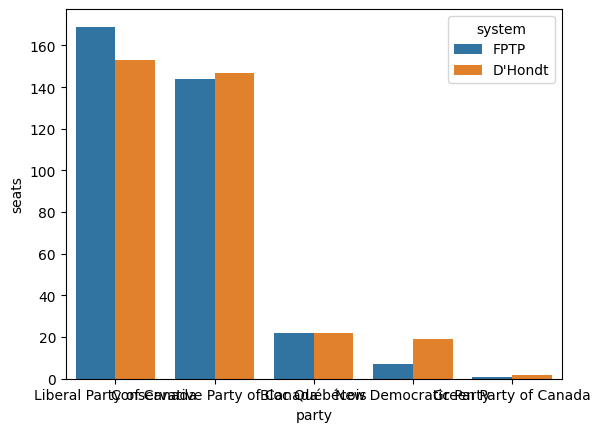

In [53]:
order = national_results_dhondt.sort_values("seats", ascending=False)["party"]
sns.barplot(data=national_results, x="party", y="seats", hue="system", order = order)
        

In [54]:
print(1)

1
